In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from pyvis.network import Network
import seaborn as sns
import pyvis

In [2]:
# Import relationship data

relationship_df = pd.read_csv('20C_countries_relationships.csv', index_col = 0)

In [3]:
relationship_df.head()

,source,target,value
27,china,japan,68
95,japan,united states,58
65,germany,united kingdom,54
61,germany,russia,53
59,germany,japan,48


In [4]:
# Creating network object

G = nx.from_pandas_edgelist(relationship_df,
                                               source = "source",
                target = "target",
                edge_attr =  "value",
                create_using = nx.Graph())

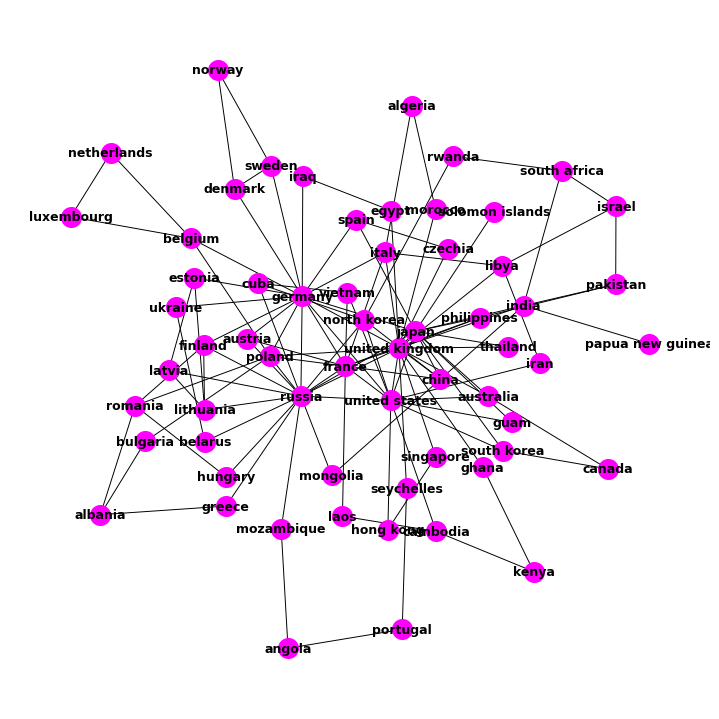

In [5]:
# Making network graph with NetworkX

h = plt.figure(figsize = (7,7))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, 
        with_labels = True, 
        node_color = 'magenta',
        node_size = 200,
        font_size = 9, 
        font_weight = 'bold',
        edge_cmap = plt.cm.Blues, 
        width = 0.7,
        pos = pos)
plt.show() 

## Creating Interactive Visualisation

In [6]:
# Define net object

net = Network()
net = Network(notebook = True,
              width="900px", 
              height="800px", 
              bgcolor='#222222', 
              font_color='white')

# Define nodes from the G object
node_degree = dict(G.degree)

# Setting up node size attributes
nx.set_node_attributes(G, node_degree, 'size')
net.from_nx(G)
net.show_buttons(filter_= True)
net.repulsion()
net.show("countries.html")

countries.html


Applying Leiden Algorithm to detect communities

In [7]:
from cdlib import algorithms
coms = algorithms.leiden(G)

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'graph_tool', 'wurlitzer', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [8]:
type(coms)

cdlib.classes.node_clustering.NodeClustering

In [9]:
new_com = coms.to_node_community_map()

In [10]:
new_com

defaultdict(list,
            {'japan': [0],
             'united states': [0],
             'united kingdom': [0],
             'australia': [0],
             'guam': [0],
             'libya': [0],
             'south korea': [0],
             'solomon islands': [0],
             'iran': [0],
             'thailand': [0],
             'hong kong': [0],
             'singapore': [0],
             'canada': [0],
             'czechia': [0],
             'philippines': [0],
             'spain': [0],
             'russia': [1],
             'poland': [1],
             'finland': [1],
             'estonia': [1],
             'latvia': [1],
             'albania': [1],
             'greece': [1],
             'hungary': [1],
             'romania': [1],
             'belarus': [1],
             'ukraine': [1],
             'lithuania': [1],
             'bulgaria': [1],
             'china': [2],
             'cuba': [2],
             'india': [2],
             'pakistan': [2],
         

In [11]:
# Put the output from new_com into a dictionary

dict_com = {k:v[0] for k,v in new_com.items()}

In [12]:
dict_com

{'japan': 0,
 'united states': 0,
 'united kingdom': 0,
 'australia': 0,
 'guam': 0,
 'libya': 0,
 'south korea': 0,
 'solomon islands': 0,
 'iran': 0,
 'thailand': 0,
 'hong kong': 0,
 'singapore': 0,
 'canada': 0,
 'czechia': 0,
 'philippines': 0,
 'spain': 0,
 'russia': 1,
 'poland': 1,
 'finland': 1,
 'estonia': 1,
 'latvia': 1,
 'albania': 1,
 'greece': 1,
 'hungary': 1,
 'romania': 1,
 'belarus': 1,
 'ukraine': 1,
 'lithuania': 1,
 'bulgaria': 1,
 'china': 2,
 'cuba': 2,
 'india': 2,
 'pakistan': 2,
 'israel': 2,
 'south africa': 2,
 'vietnam': 2,
 'north korea': 2,
 'mongolia': 2,
 'rwanda': 2,
 'papua new guinea': 2,
 'germany': 3,
 'france': 3,
 'italy': 3,
 'egypt': 3,
 'denmark': 3,
 'norway': 3,
 'austria': 3,
 'sweden': 3,
 'algeria': 3,
 'morocco': 3,
 'iraq': 3,
 'angola': 4,
 'portugal': 4,
 'mozambique': 4,
 'seychelles': 4,
 'cambodia': 5,
 'laos': 5,
 'ghana': 5,
 'kenya': 5,
 'belgium': 6,
 'netherlands': 6,
 'luxembourg': 6}

In [15]:
# Rerun network graph with communities as an argument

nx.set_node_attributes(G, dict_com, 'group')
com_net = Network(notebook = True, 
                  width="1300px", 
                  height="700px", 
                  bgcolor='#222222', 
                  font_color='white')
com_net.from_nx(G)
# Setting larger font size for all nodes
for node in com_net.nodes:
    node['font'] = {
        'size': 20,
        'color': 'white' 
    }
com_net.show_buttons(filter_ = True)
com_net.repulsion()
com_net.show("countries_communities_leiden.html")

countries_communities_leiden.html


While not every single link is intuitively clear, overall the network map and links between different countries make sense.
There are a lot of simple geographical groupings that are accurate (Benelux; Denmark, Sweden and Norway off by themselves), and we see that the large geopolitical powers that were involved in a lot of war have large central nodes (e.g., Germany, Russia, US, UK, Japan).

## Calculating Centrality Measures

In [16]:
# Degree centrality

degree_dict = nx.degree_centrality(G)
degree_dict

{'china': 0.09836065573770492,
 'japan': 0.21311475409836067,
 'united states': 0.21311475409836067,
 'germany': 0.26229508196721313,
 'united kingdom': 0.3114754098360656,
 'russia': 0.27868852459016397,
 'france': 0.18032786885245902,
 'poland': 0.11475409836065574,
 'italy': 0.0819672131147541,
 'cuba': 0.04918032786885246,
 'finland': 0.06557377049180328,
 'australia': 0.06557377049180328,
 'belgium': 0.06557377049180328,
 'india': 0.09836065573770492,
 'guam': 0.03278688524590164,
 'egypt': 0.03278688524590164,
 'libya': 0.06557377049180328,
 'estonia': 0.04918032786885246,
 'latvia': 0.04918032786885246,
 'denmark': 0.04918032786885246,
 'norway': 0.03278688524590164,
 'albania': 0.04918032786885246,
 'greece': 0.03278688524590164,
 'pakistan': 0.04918032786885246,
 'south korea': 0.04918032786885246,
 'cambodia': 0.04918032786885246,
 'israel': 0.04918032786885246,
 'south africa': 0.04918032786885246,
 'austria': 0.04918032786885246,
 'solomon islands': 0.01639344262295082,
 's

In [17]:
# Converting to df
degree_df = pd.DataFrame(degree_dict.items(), columns=['country','centrality'])

In [18]:
# Sorting by centrality
degree_df.sort_values(by = ['centrality'], 
                      ascending=False, 
                      inplace = True)

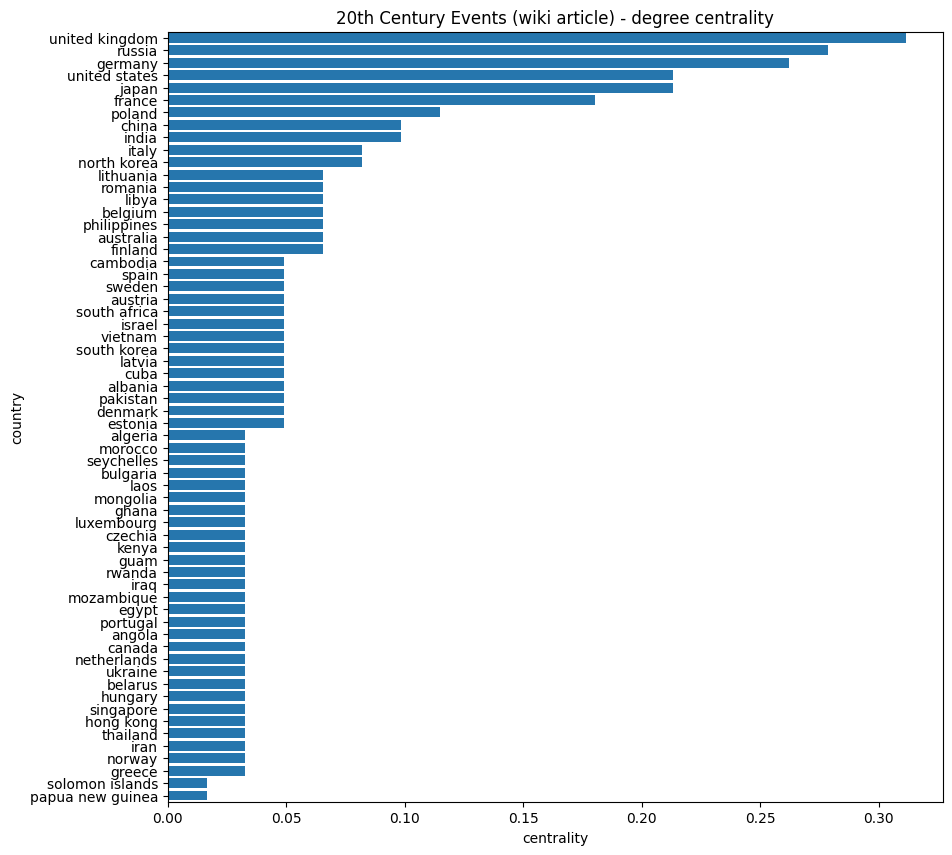

In [20]:
# Plot the degree centrality

plt.figure(figsize = (10, 10))

sns.barplot(x = "centrality", y = "country",
    saturation = 0.9, 
    data = degree_df)
plt.title("20th Century Events (wiki article) - degree centrality")
plt.show()

A lot of this makes snes in terms of the large powers having the highest centrality. Some countries seem slightly inflated (e.g., Poland) or underestimated (e.g. Egypt), and I would mainly put this down to the Eurocentrism and WW2 focus of the article contents

In [21]:
# Closeness centrality

closeness_dict = nx.closeness_centrality(G)
closeness_df = pd.DataFrame(closeness_dict.items(), columns=['country','centrality'])

In [22]:
# sorting
closeness_df.sort_values(by = ['centrality'], 
                         ascending=False, 
                         inplace = True)

Text(0.5, 1.0, '20th Century Events (wiki article) - closeness centrality')

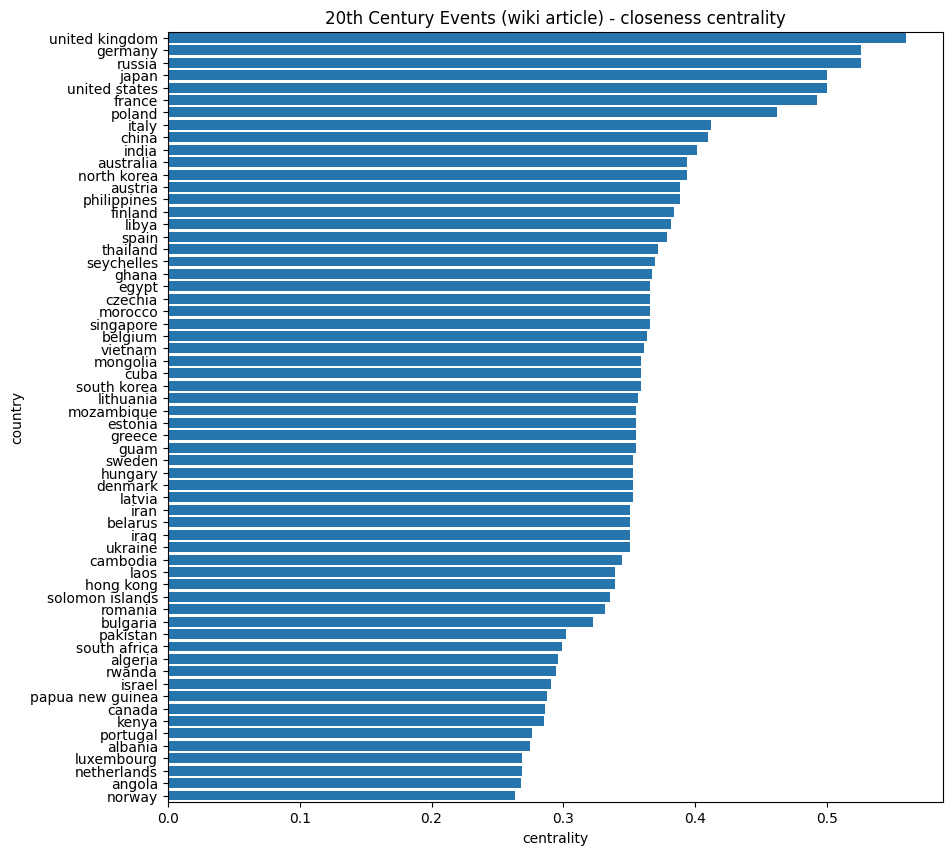

In [23]:
plt.figure(figsize = (10, 10))

sns.barplot(x = "centrality", y = "country",
    saturation = 0.9, 
    data = closeness_df)
plt.title("20th Century Events (wiki article) - closeness centrality")

I would think the United States should have the highest closeness centrality as the worlds largest superpower and being so involved in geopolitics, especially in the second half of the 20th Century. Again I think UK, Russia, Germany and Japan being so high shows the article's overproportional focus on world wars 1 and 2.

In [24]:
# Betweenness centrality
    # making df
betweenness_dict = nx.betweenness_centrality(G)
betweennes_df = pd.DataFrame(betweenness_dict.items(), columns=['country','centrality'])

In [25]:
# sorting
betweennes_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

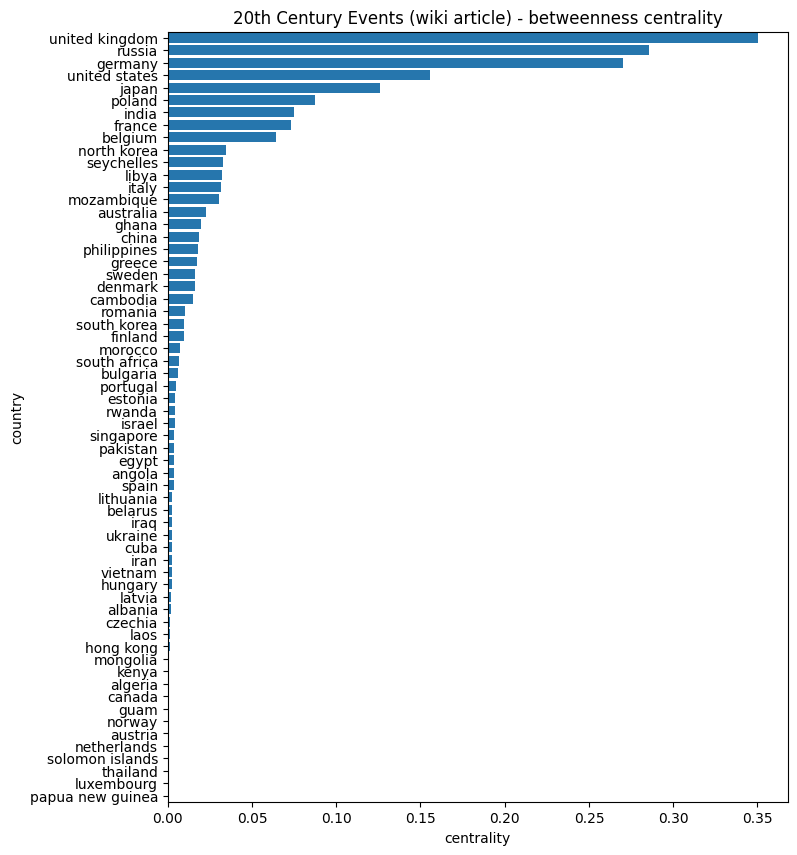

In [26]:
plt.figure(figsize = (8, 10))

sns.barplot(x = "centrality", y = "country",
    saturation = 0.9, data = betweennes_df)
plt.title("20th Century Events (wiki article) - betweenness centrality")

plt.show()

Quite similar takeaways here as previous graphs (European WW2 countries overinflated, US underestimated), except China here is even more severely under-estimated 